# Request & Grant Deadlines and Ambiguous Union (p. 13)

Two case studies from page 13 of the EMSOFT draft.

**Part A** (eqs 20–23) — Request & Grant with $k$ deadline types:
expressions $e_{T_i}$, $e_\mathcal{T}$, $e'_\mathcal{T}$, $e''_\mathcal{T}$
are constructed automatically from a deadline list.
We show volume curves and a scaling plot for $e''_\mathcal{T}$ (k up to 8).

**Part B** (eqs 24–28) — Ambiguous union $e_{\mathrm{ex}\cup}$:
volume identity $V^{e_\cup} = V^\mathcal{M} - V^{e_\cap}$;
rejection rate plotted over each curve's own support interval.


In [1]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import sys, os, time, random
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.size": 11,
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.serif": [],
    "font.weight": "normal",
    "figure.dpi": 110,
})

def _find_repo_root():
    try:
        d = os.path.abspath(os.getcwd())
    except (FileNotFoundError, OSError):
        d = '/workspace'
    while True:
        if os.path.isfile(os.path.join(d, "parse", "quickparse.py")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("repo root not found")
        d = parent

REPO = _find_repo_root()
for p in [REPO, os.path.join(REPO, "experiments", "paper_experiments")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from parse.quickparse import quickparse
from sample.sample import sample
from volume.slice_volume import slice_volume

random.seed(42); np.random.seed(42)

RESULTS = os.path.join(REPO, "experiments", "paper_experiments",
                       "12_page13_casestudy", "results")
os.makedirs(RESULTS, exist_ok=True)

# Quick smoke test
_phi = quickparse("<a>_[0,1] *", string=True)
_w   = sample(_phi, 3)
print("VolTRE OK:", _w)


VolTRE OK: (0.389, a),(0.816, a),(0.485, a)


---
## Part A: Request & Grant (eqs 20–23)

### Setting

There are $k$ request types $r_1, \ldots, r_k$ with deadlines
$T_1 \le T_2 \le \cdots \le T_k$.
A shared grant event $g$ must answer each $r_i$ within $T_i$ time units.
In each cycle a single $g$ answers all pending requests;
any subset of request types may arrive before the grant.

### The four expressions

| Eq | Name | Meaning | VolTRE |
|---|---|---|---|
| (20) | $e_{T_i}$ | One type $r_i$, answered by $g$ within $T_i$ | ✓ volume + sample |
| (21) | $e_\mathcal{T} = \bigcap_i e_{T_i}$ | All $k$ types simultaneously | ⚠ sample only (intersection budget); no volume |
| (22) | $e'_\mathcal{T}$ | Ordered cycle: $r_1{\to}g{\to}r_2{\to}g{\to}\cdots$, $2k$ events | ✗ no analytic volume; sampling degenerates for $k\ge 2$ |
| (23) | $e''_\mathcal{T}$ | Nested: $(r_k?)\cdots(r_1?){\cdot}g$, optional requests, 1 shared grant | ✓ volume + sample, **1 TA clock** |

The key result of eq 23: $e''_\mathcal{T}$ uses only **1 clock** in its TA encoding
regardless of $k$, while a TA encoding of $e'_\mathcal{T}$ needs $k$ clocks.


In [2]:
def build_e_single(r, T):
    # eq 20: r_i always answered by g within T_i.
    s = f"(<{r} . g>_[0,{T}]) *"
    return quickparse(s, string=True), s

def build_e_T(deadlines):
    # eq 21: e_T = intersection of all e_{T_i}.
    # VolTRE can SAMPLE from this (rejection budget) but cannot compute its volume
    # (slice_volume raises ValueError for & subexpressions).
    parts = [f"((<{r} . g>_[0,{T}]) *)" for r, T in deadlines]
    s = " & ".join(parts)
    return quickparse(s, string=True), s

def build_e_prime(deadlines):
    # eq 22: e'_T = e_T & ((EPS + r_Tk) . ... . (EPS + r_T1) . g)*
    # Same optional-request body as e''_T but without nested timing.
    # Timing is enforced by the intersection with e_T.
    # Hard to sample (multiple intersections); no analytic volume.
    #
    # Structured as right-fold: e_T1 & (e_T2 & (... & kleene))
    # so that sample() always sees a plain Kleene as child1 (needed for
    # disambiguate), while match() handles the nested intersections in child2.
    body = " . ".join(f"(EPS + {r})" for r, T in reversed(deadlines))
    s = f"({body} . g) *"
    for r, T in reversed(deadlines):  # wrap from Tk down to T1 so T1 is outermost
        s = f"((<{r} . g>_[0,{T}]) *) & ({s})"
    return quickparse(s, string=True), s

def build_e_dprime(deadlines):
    # eq 23: nested timed, requests optional via EPS.
    # Each cycle: (EPS + r_k) . ... . (EPS + r_1) . g
    # At most k+1 events per cycle; g is the single shared grant.
    # Uses only 1 clock in the TA encoding, regardless of k.
    r1, T1 = deadlines[0]
    inner = f"<(EPS + {r1}) . g>_[0,{T1}]"
    for r_i, T_i in deadlines[1:]:
        inner = f"<(EPS + {r_i}) . {inner}>_[0,{T_i}]"
    s = f"({inner}) *"
    return quickparse(s, string=True), s

We try first for 
- r1... 1 time unit request
- r3... 3 time unit request
- r7... 7 time unit request

In [3]:
# Deadline list — change here and it propagates everywhere.
# First 3 entries are the paper's concrete example (r1, r3, r7).
DEADLINES_DEMO = [
    ("r1",  1), ("r3",  3), ("r7",  7),("r10", 10)
]
# DEADLINES_DEMO = [
#     ("r1",  1), ("r3",  3), ("r7",  7),
#     ("r10", 10), ("r15", 15), ("r21", 21), ("r28", 28),
# ]

for k in range(1, len(DEADLINES_DEMO)+1):
    dl = DEADLINES_DEMO[:k]
    print(dl)
    ri_labels = ", ".join(f"T_{j+1}={T}" for j, (r, T) in enumerate(dl))
    print(f"\n-- k={k}  ({ri_labels}) --")

    _, s = build_e_single(dl[0][0], dl[0][1])
    print(f"  e_T1       : {s}")

    _, s = build_e_T(dl)
    print(f"  e_T (eq21) : {s}")

    _, s = build_e_prime(dl)
    print(f"  e'_T (eq22): {s}")

    _, s = build_e_dprime(dl)
    print(f"  e''_T (eq23): {s}")


[('r1', 1)]

-- k=1  (T_1=1) --
  e_T1       : (<r1 . g>_[0,1]) *
  e_T (eq21) : ((<r1 . g>_[0,1]) *)
  e'_T (eq22): ((<r1 . g>_[0,1]) *) & (((EPS + r1) . g) *)
  e''_T (eq23): (<(EPS + r1) . g>_[0,1]) *
[('r1', 1), ('r3', 3)]

-- k=2  (T_1=1, T_2=3) --
  e_T1       : (<r1 . g>_[0,1]) *
  e_T (eq21) : ((<r1 . g>_[0,1]) *) & ((<r3 . g>_[0,3]) *)
  e'_T (eq22): ((<r1 . g>_[0,1]) *) & (((<r3 . g>_[0,3]) *) & (((EPS + r3) . (EPS + r1) . g) *))
  e''_T (eq23): (<(EPS + r3) . <(EPS + r1) . g>_[0,1]>_[0,3]) *
[('r1', 1), ('r3', 3), ('r7', 7)]

-- k=3  (T_1=1, T_2=3, T_3=7) --
  e_T1       : (<r1 . g>_[0,1]) *
  e_T (eq21) : ((<r1 . g>_[0,1]) *) & ((<r3 . g>_[0,3]) *) & ((<r7 . g>_[0,7]) *)
  e'_T (eq22): ((<r1 . g>_[0,1]) *) & (((<r3 . g>_[0,3]) *) & (((<r7 . g>_[0,7]) *) & (((EPS + r7) . (EPS + r3) . (EPS + r1) . g) *)))
  e''_T (eq23): (<(EPS + r7) . <(EPS + r3) . <(EPS + r1) . g>_[0,1]>_[0,3]>_[0,7]) *
[('r1', 1), ('r3', 3), ('r7', 7), ('r10', 10)]

-- k=4  (T_1=1, T_2=3, T_3=7, T_4=10) --

In [4]:
N = 10

# Sanity: for each k, sample one word from every individual e_{T_i} and from e''_T
for k in range(1, len(DEADLINES_DEMO)+1):
    dl = DEADLINES_DEMO[:k]
    print(f"k={k}")

    for i, (r, T) in enumerate(dl, 1):
        phi, _ = build_e_single(r, T)
        w = sample(phi, N)
        print(f"  e_T{i} (n={N})  : {w}")

    phi, _ = build_e_dprime(dl)
    w = sample(phi, N)
    print(f"  e''_T (n={N}) : {w}")
    print()


k=1
  e_T1 (n=10)  : (0.053, r1),(0.052, g),(0.222, r1),(0.185, g),(0.005, r1),(0.767, g),(0.121, r1),(0.658, g),(0.049, r1),(0.479, g)
  e''_T (n=10) : (0.870, g),(0.978, g),(0.796, g),(0.033, r1),(0.690, g),(0.060, g),(0.300, g),(0.510, g),(0.911, g),(0.062, g)

k=2
  e_T1 (n=10)  : (0.550, r1),(0.437, g),(0.163, r1),(0.549, g),(0.053, r1),(0.197, g),(0.439, r1),(0.231, g),(0.087, r1),(0.102, g)
  e_T2 (n=10)  : (1.150, r3),(0.131, g),(0.684, r3),(0.658, g),(0.621, r3),(0.369, g),(0.995, r3),(1.612, g),(2.633, r3),(0.078, g)
  e''_T (n=10) : (0.221, r3),(0.608, g),(0.255, g),(0.303, g),(0.304, r3),(0.195, g),(0.001, r3),(0.975, g),(0.501, r3),(0.101, g)

k=3
  e_T1 (n=10)  : (0.652, r1),(0.205, g),(0.359, r1),(0.294, g),(0.207, r1),(0.769, g),(0.283, r1),(0.625, g),(0.331, r1),(0.424, g)
  e_T2 (n=10)  : (0.290, r3),(0.969, g),(0.142, r3),(0.478, g),(0.657, r3),(2.104, g),(1.037, r3),(0.071, g),(1.846, r3),(0.507, g)
  e_T3 (n=10)  : (1.735, r7),(1.980, g),(0.494, r7),(4.527, g),(0.7

In [5]:
N_VOL = 10

# e'_T (eq 22): why it is hard to work with
# - slice_volume raises an error: the expression contains intersection (&)
# - sampling degenerates for k>=2: the right-fold sampler draws from e_T1
#   (only r1,g pairs), which the e_T2 partner intersection never accepts

colors_k = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}

for k in range(1, len(DEADLINES_DEMO)+1):
    dl = DEADLINES_DEMO[:k]
    phi, s = build_e_prime(dl)
    print(f"k={k}  e'_T = {s}")

    try:
        vp = slice_volume(phi, N_VOL)
        print(f"  volume: unexpected success")
    except Exception as e:
        print(f"  volume: {type(e).__name__} — no analytic volume (expression contains intersection)")

    N_TRIES = 1
    successes = 0
    for _ in range(N_TRIES):
        try:
            w = sample(phi, N_VOL)
            print(f"  sample OK: {w}")
            successes += 1
        except Exception as e:
            print(f"  sample failed: {type(e).__name__}")
    if successes == 0:
        print(f"  -> 0/{N_TRIES} successful samples")
    print()


k=1  e'_T = ((<r1 . g>_[0,1]) *) & (((EPS + r1) . g) *)
  volume: ValueError — no analytic volume (expression contains intersection)
  sample OK: (0.960, r1),(0.029, g),(0.107, r1),(0.884, g),(0.547, r1),(0.355, g),(0.170, r1),(0.496, g),(0.728, r1),(0.059, g)

k=2  e'_T = ((<r1 . g>_[0,1]) *) & (((<r3 . g>_[0,3]) *) & (((EPS + r3) . (EPS + r1) . g) *))
  volume: ValueError — no analytic volume (expression contains intersection)
Did 100 rejections.
Did 100 rejections.
Did 100 rejections.
Did 100 rejections.
  sample failed: BudgetExhaustedException
  -> 0/1 successful samples

k=3  e'_T = ((<r1 . g>_[0,1]) *) & (((<r3 . g>_[0,3]) *) & (((<r7 . g>_[0,7]) *) & (((EPS + r7) . (EPS + r3) . (EPS + r1) . g) *)))
  volume: ValueError — no analytic volume (expression contains intersection)
Did 100 rejections.
Did 100 rejections.
Did 100 rejections.
Did 100 rejections.
  sample failed: BudgetExhaustedException
  -> 0/1 successful samples

k=4  e'_T = ((<r1 . g>_[0,1]) *) & (((<r3 . g>_[0,3]) *)

In [6]:
# --- compute: volume polynomials for e''_T, one per k ---
vps = {}
for k in range(1, len(DEADLINES_DEMO) + 1):
    dl = DEADLINES_DEMO[:k]
    phi, _ = build_e_dprime(dl)
    vps[k] = {"vp": slice_volume(phi, N_VOL), "T_max": dl[-1][1], "dl": dl}
    print(f"k={k}  T_max={dl[-1][1]}  computed")


k=1  T_max=1  computed
k=2  T_max=3  computed
k=3  T_max=7  computed
k=4  T_max=10  computed


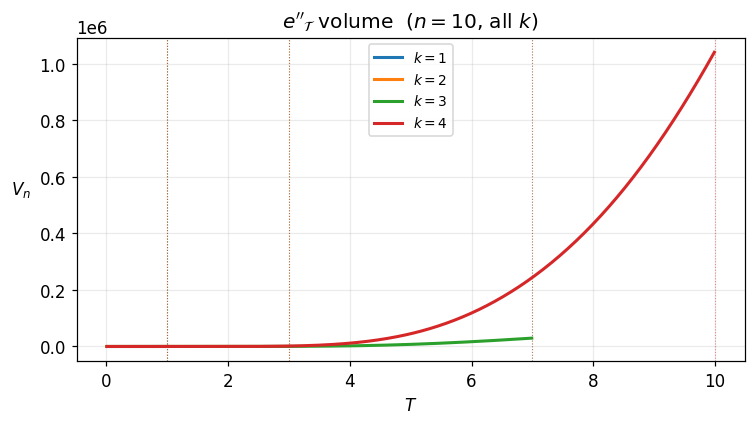

Saved overlay


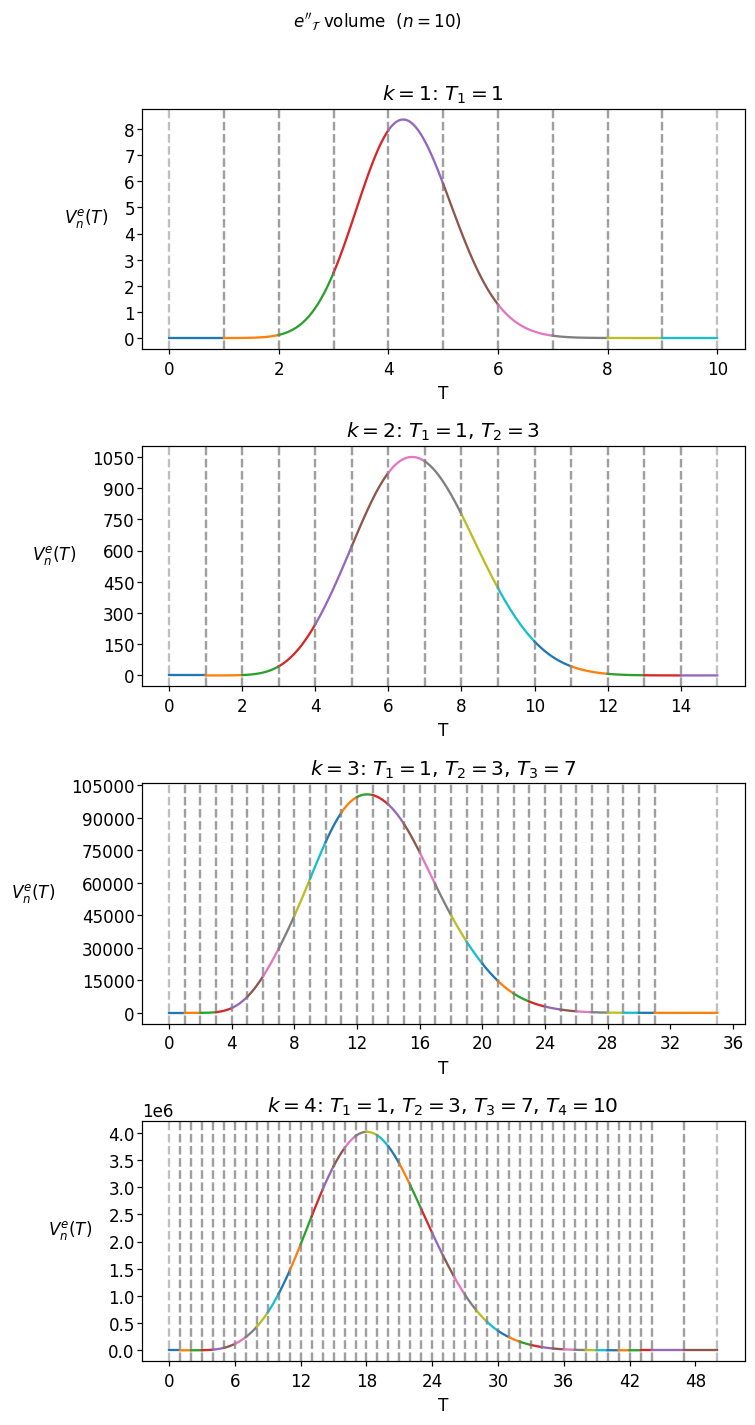

Saved stacked


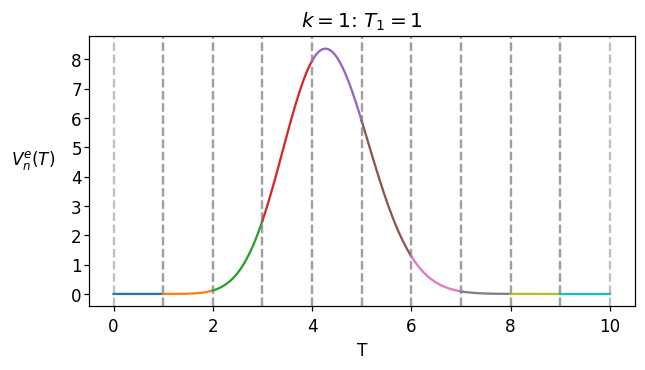

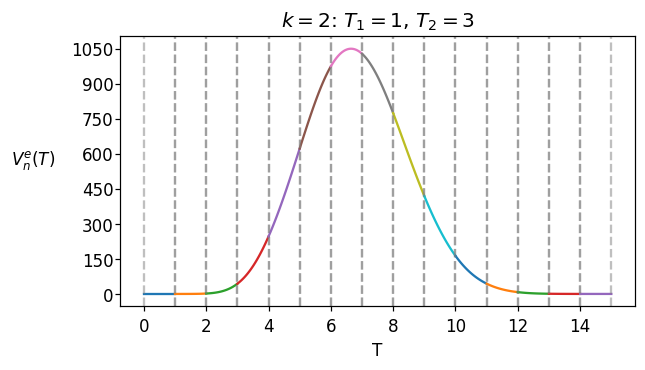

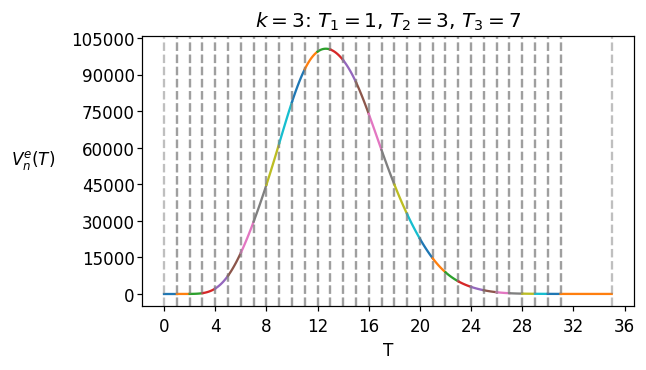

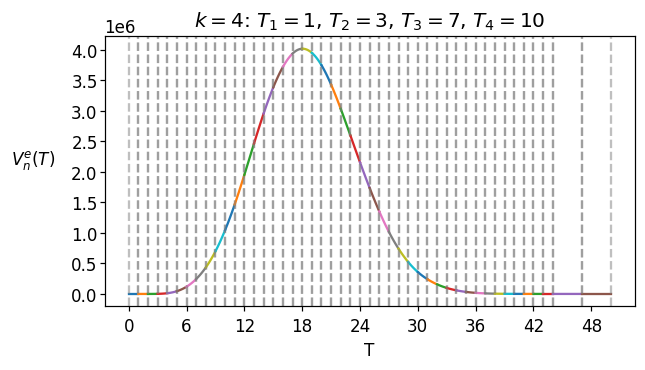

Saved separate figures


In [7]:
# --- plot: change VIZ_MODE to switch layout ---
# "overlay"  : all k in one axes (manual evaluation on a grid)
# "stacked"  : one panel per k, stacked vertically, using vp.plot()
# "separate" : one figure per k printed individually, using vp.plot()
# "all"      : produce all three
VIZ_MODE = "all"

color_k = {k: plt.get_cmap("tab10")(i) for i, k in enumerate(sorted(vps))}

# overlay
if VIZ_MODE in ("overlay", "all"):
    fig, ax = plt.subplots(figsize=(7, 4))
    for k, d in vps.items():
        vp, T_max = d["vp"], d["T_max"]
        T_vals = np.linspace(0.01, T_max - 0.01, 300)
        vols = [float(vp(T)) if vp(T) else float("nan") for T in T_vals]
        ax.plot(T_vals, vols, color=color_k[k], lw=2, label=f"$k={k}$")
        for _, T_i in d["dl"]:
            ax.axvline(T_i, color=color_k[k], lw=0.7, ls=":", alpha=0.5)
    ax.set_xlabel("$T$")
    ax.set_ylabel(r"$V_n$", rotation=0, labelpad=12)
    ax.set_title(f"$e''_\\mathcal{{T}}$ volume  ($n={N_VOL}$, all $k$)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(os.path.join(RESULTS, "12_partA_volumes_overlay.pdf"), bbox_inches="tight")
    plt.show()
    print("Saved overlay")

# stacked (one row per k, vp.plot() per panel)
if VIZ_MODE in ("stacked", "all"):
    K_list = sorted(vps)
    fig, axes = plt.subplots(len(K_list), 1, figsize=(7, 3.2 * len(K_list)), sharex=False)
    if len(K_list) == 1:
        axes = [axes]
    for ax, k in zip(axes, K_list):
        plt.sca(ax)
        d = vps[k]
        title = f"$k={k}$: " + ", ".join(f"$T_{{{i+1}}}={T}$" for i,(r,T) in enumerate(d["dl"]))
        d["vp"].plot(no_show=True, plt_title=title)
    fig.suptitle(f"$e''_\\mathcal{{T}}$ volume  ($n={N_VOL}$)", fontsize=11, y=1.01)
    fig.tight_layout()
    fig.savefig(os.path.join(RESULTS, "12_partA_volumes_stacked.pdf"), bbox_inches="tight")
    plt.show()
    print("Saved stacked")

# separate figures per k
if VIZ_MODE in ("separate", "all"):
    for k, d in vps.items():
        plt.figure(figsize=(6, 3.5))
        title = f"$k={k}$: " + ", ".join(f"$T_{{{i+1}}}={T}$" for i,(r,T) in enumerate(d["dl"]))
        d["vp"].plot(no_show=True, plt_title=title)
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS, f"12_partA_volumes_k{k}.pdf"), bbox_inches="tight")
        plt.show()
    print("Saved separate figures")


k= 1  n=10  [T_1=1]: mean=0.553s  std=0.520s
k= 2  n=10  [T_1=1, T_2=3]: mean=0.804s  std=1.606s
k= 3  n=10  [T_1=1, T_2=3, T_3=7]: mean=1.704s  std=4.300s
k= 4  n=10  [T_1=1, T_2=3, T_3=7, T_4=10]: mean=2.907s  std=6.983s
k= 5  n=10  [T_1=1, T_2=3, T_3=7, T_4=10]: mean=0.485s  std=0.188s
k= 6  n=10  [T_1=1, T_2=3, T_3=7, T_4=10]: mean=0.397s  std=0.086s
k= 7  n=10  [T_1=1, T_2=3, T_3=7, T_4=10]: mean=0.417s  std=0.089s


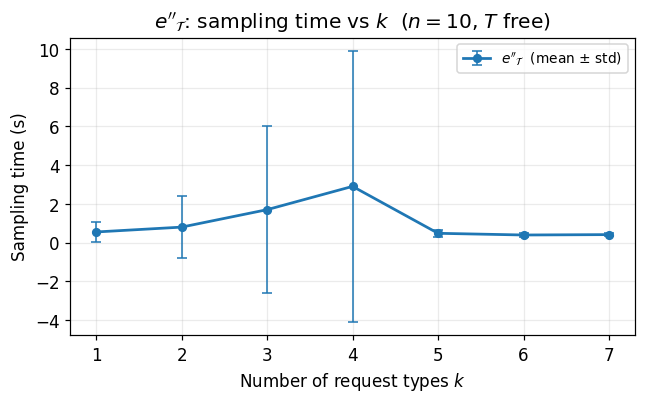

Saved 12_partA_scaling.pdf


In [8]:
import time as _time

K_MAX    = 7
N_REPS   = 10
N_length = 10

k_vals, mean_times, std_times = [], [], []

for k in range(1, K_MAX + 1):
    dl     = DEADLINES_DEMO[:k]
    phi, _ = build_e_dprime(dl)
    dl_str = ", ".join(f"T_{i+1}={T}" for i,(r,T) in enumerate(dl))

    ts = []
    print(f"k={k:2d}  n={N_length}  [{dl_str}]: ", end="", flush=True)
    for _ in range(N_REPS):
        t0 = _time.perf_counter()
        try:
            sample(phi, N_length)
            ts.append(_time.perf_counter() - t0)
        except Exception as e:
            print(f"fail({type(e).__name__}) ", end="")

    if ts:
        m = float(np.mean(ts)); s = float(np.std(ts))
        k_vals.append(k); mean_times.append(m); std_times.append(s)
        print(f"mean={m:.3f}s  std={s:.3f}s")
    else:
        print("all failed")

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.errorbar(k_vals, mean_times, yerr=std_times,
            color="#1f77b4", marker="o", markersize=5, lw=1.8,
            capsize=3, elinewidth=1, label=r"$e''_\mathcal{T}$  (mean $\pm$ std)")
ax.set_xlabel("Number of request types $k$")
ax.set_ylabel("Sampling time (s)")
ax.set_title(f"$e''_\\mathcal{{T}}$: sampling time vs $k$  ($n={N_length}$, $T$ free)")
ax.set_xticks(k_vals)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "12_partA_scaling.pdf"), bbox_inches="tight")
plt.show()
print("Saved 12_partA_scaling.pdf")


### Interpretation

**Volume curves:**
- $k=1$: volume grows from 0, saturates at $T_1$ (constraint becomes non-binding).
- $k=2$: zero below $T_1$, grows as a polynomial, saturates near $T_2$.
- $k=3$: same pattern one level deeper; dotted verticals mark each $T_i$.
- $e'_\mathcal{T}$ ($2k$ events/cycle) and $e''_\mathcal{T}$ (up to $k{+}1$ events/cycle)
  describe related but different languages: $e'_\mathcal{T}$ requires one grant per
  request type, $e''_\mathcal{T}$ uses one shared grant for all present requests.

**Scaling curve ($T_i = i$):**
- Sampling time grows slowly with $k$ (roughly polynomial).
- A TA encoding of $e'_\mathcal{T}$ needs $k$ clocks — exponential state blowup.
  VolTRE's algebraic approach avoids this entirely.

**Nicolas's next step:** run TA sampler for the same expressions at
$k = 5, 10, 15$ and overlay on this plot.


---
## Part B: Ambiguous Union (paper eqs 24-28)

### The expression

The paper considers the union

$$e_{\mathrm{ex}\cup}
  = \underbrace{\langle aa\rangle^*_{\leq 1}\langle a\rangle_{\leq 1}}_{e_{\mathrm{left}}}
  \cup
  \underbrace{\langle a\rangle_{\leq 1}\langle aa\rangle^*_{\leq 1}}_{e_{\mathrm{right}}}$$

- $e_{\mathrm{left}}$: zero or more $aa$-pairs (each within $\leq 1$), then one final $a$ (within $\leq 1$).
  Word lengths are odd: $n = 1, 3, 5, \ldots$
- $e_{\mathrm{right}}$: one $a$ (within $\leq 1$), then zero or more $aa$-pairs (each within $\leq 1$).
  Same word lengths, symmetric structure.

The two branches overlap: any word $w$ with $n \geq 3$ events that fits both timing
constraints belongs to the **intersection** $e_{\mathrm{ex}\cap} = e_{\mathrm{left}} \cap e_{\mathrm{right}}$.
This makes the union **ambiguous** — such a word has two distinct parse trees.

### How VolTRE computes volumes for a union

`slice_volume` on a union **sums the branch volumes** without doing
inclusion-exclusion.  Call this the *multiset volume*:

$$V_n^{\mathcal{M}}(T) := V_n^{e_{\mathrm{left}}}(T) + V_n^{e_{\mathrm{right}}}(T) = 2\,V_n^{e_{\mathrm{left}}}(T)$$

(the two branches are symmetric, so both volumes are equal).
Words in the intersection are **counted twice** in $V^{\mathcal{M}}$.

The true set-theoretic union volume follows by inclusion-exclusion (paper eq 24/25):

$$\boxed{V_n^{e_{\mathrm{ex}\cup}}(T)
  = V_n^{\mathcal{M}}(T) - V_n^{e_{\mathrm{ex}\cap}}(T)}$$

### How VolTRE samples from an ambiguous union (smart rejection)

VolTRE's sampler (`sample.py`, `smart_sampling`) draws from $V^{\mathcal{M}}$
uniformly, then corrects for the overcounting:

1. Draw a timed word $w$ uniformly from the *disambiguated* expression
   (each branch is labelled so duplicates are distinguishable).
2. Count $N(w)$ = number of parse trees of $w$ in the original expression.
   For $w \notin e_{\mathrm{ex}\cap}$: $N(w) = 1$.  For $w \in e_{\mathrm{ex}\cap}$: $N(w) = 2$.
3. Accept with probability $1/N(w)$, else reject and restart.

This turns a uniform draw from $V^{\mathcal{M}}$ into a uniform draw from
$V^{e_{\mathrm{ex}\cup}}$ (the *true* uniform distribution, not the multiset one).

### Measuring $V^{e_{\mathrm{ex}\cap}}$ via the rejection rate

`sample(..., feedback=True)` returns a `Feedback` namedtuple with field
`smart_rej` = number of restarts before acceptance for that one sample.

Over $K$ successful samples with a total of $R$ restarts,
the empirical rejection rate is $\hat p_{\mathrm{rej}} = R / (K + R)$.

Why does this equal $V^{e_{\mathrm{ex}\cap}} / V^{\mathcal{M}}$?
Because intersection words appear in **two** branches in the disambiguated
expression, so they are drawn with probability $2\,V^{e_{\mathrm{ex}\cap}} / V^{\mathcal{M}}$,
and each such draw is rejected with probability $1/2$ (step 3).
Hence $P(\text{reject a draw}) = V^{e_{\mathrm{ex}\cap}} / V^{\mathcal{M}}$, and so

$$\hat V_n^{e_{\mathrm{ex}\cap}}(T) = \hat p_{\mathrm{rej}}(T) \cdot V_n^{\mathcal{M}}(T)$$

The three plots below verify this identity and show how $p_{\mathrm{rej}}$ varies with $T$.


In [9]:
# Paper expressions (eq 24-28)
# e_left  = <aa>*_<=1 . <a>_<=1   (zero-or-more aa-pairs each <=1, then one a <=1)
# e_right = <a>_<=1  . <aa>*_<=1  (one a <=1, then zero-or-more aa-pairs each <=1)
# e_union = e_left + e_right        (union; word lengths must be odd: n=1,3,5,...)
# e_inter = e_left & e_right        (intersection; non-trivial for n>=3)
phi_left  = quickparse("<a . a>_[0,1] * . <a>_[0,1]",  string=True)
phi_right = quickparse("<a>_[0,1] . <a . a>_[0,1] *",  string=True)
phi_union = quickparse(
    "(<a . a>_[0,1] * . <a>_[0,1]) + (<a>_[0,1] . <a . a>_[0,1] *)",
    string=True)
phi_inter = quickparse(
    "(<a . a>_[0,1] * . <a>_[0,1]) & (<a>_[0,1] . <a . a>_[0,1] *)",
    string=True)

# Sanity: sample a few words from each expression
for name, phi in [("e_left", phi_left), ("e_right", phi_right),
                  ("e_union", phi_union), ("e_inter", phi_inter)]:
    w = sample(phi, 3, T=0.8)
    print(f"{name:8s}  n=3 T=0.8 :  {w}")


e_left    n=3 T=0.8 :  (0.599, a),(0.053, a),(0.148, a)
e_right   n=3 T=0.8 :  (0.265, a),(0.486, a),(0.049, a)
e_union   n=3 T=0.8 :  (0.167, a),(0.301, a),(0.332, a)
e_inter   n=3 T=0.8 :  (0.021, a),(0.172, a),(0.607, a)


In [10]:
# Sanity: show rejection feedback for a handful of union samples
# smart_rej > 0 means the word was in the intersection and took multiple draws
print("phi_union samples (n=3, T=0.8) with smart_rej count:")
for _ in range(8):
    w, fb = sample(phi_union, 3, T=0.8, feedback=True)
    marker = "  <-- intersection word (rejected before)" if fb.smart_rej > 0 else ""
    print(f"  {w}  [smart_rej={fb.smart_rej}]{marker}")


phi_union samples (n=3, T=0.8) with smart_rej count:
  (0.159, a),(0.578, a),(0.063, a)  [smart_rej=0]
  (0.010, a),(0.439, a),(0.351, a)  [smart_rej=2]  <-- intersection word (rejected before)
  (0.512, a),(0.202, a),(0.086, a)  [smart_rej=0]
  (0.124, a),(0.172, a),(0.504, a)  [smart_rej=1]  <-- intersection word (rejected before)
  (0.281, a),(0.146, a),(0.373, a)  [smart_rej=0]
  (0.087, a),(0.267, a),(0.446, a)  [smart_rej=1]  <-- intersection word (rejected before)
  (0.402, a),(0.210, a),(0.189, a)  [smart_rej=2]  <-- intersection word (rejected before)
  (0.014, a),(0.440, a),(0.346, a)  [smart_rej=0]


### Computing $V^{\mathcal{M}}$ and estimating $V^{e_{\mathrm{ex}\cap}}$

For each $(n, T)$ we:
1. Compute $V_n^{\mathcal{M}}(T)$ exactly via `slice_volume(phi_union, n)` evaluated at $T$.
2. Collect $K = 30$ samples from `phi_union` with `feedback=True`, summing up `smart_rej` counts.
3. Estimate $\hat p_{\mathrm{rej}}(T) = R / (K + R)$ and hence
   $\hat V^{e_{\mathrm{ex}\cap}}(T) = \hat p_{\mathrm{rej}}(T) \cdot V^{\mathcal{M}}(T)$.

We run this for $n = 3, 5, 7$ (odd, the only supported lengths) over $T \in (0, 2)$.


In [11]:
# T_max for e_left = (<aa>_[0,1]* . <a>_[0,1]): (n+1)/2 for odd n
T_MAX  = {3: 2.0, 5: 3.0, 7: 4.0}
N_SAMPLE = 30

partB = {}
for n in [3, 5, 7]:
    T_hi   = T_MAX[n]
    T_grid = np.linspace(0.05, T_hi - 0.05, 40)
    v_M_arr, v_inter_arr, p_rej_arr, T_ok = [], [], [], []
    print(f"n={n}  T in (0, {T_hi}) ...", end="", flush=True)

    vu_poly = slice_volume(phi_union, n)

    for T_np in T_grid:
        T = float(T_np)
        try:
            vm = float(vu_poly(T))
            if vm <= 1e-15:
                continue

            smart_rej_counts = [
                sample(phi_union, n, T=T, feedback=True)[1].smart_rej
                for _ in range(N_SAMPLE)
            ]
            R = sum(smart_rej_counts)
            K = N_SAMPLE
            p_rej   = R / (K + R)
            v_inter = vm * p_rej

            v_M_arr.append(vm); v_inter_arr.append(v_inter)
            p_rej_arr.append(p_rej); T_ok.append(T)
        except Exception:
            pass

    partB[n] = dict(T=T_ok, v_M=v_M_arr, v_inter=v_inter_arr, p_rej=p_rej_arr)
    print(f" {len(T_ok)} points OK")

print("Done.")


n=3  T in (0, 2.0) ... 40 points OK
n=5  T in (0, 3.0) ... 40 points OK
n=7  T in (0, 4.0) ... 40 points OK
Done.


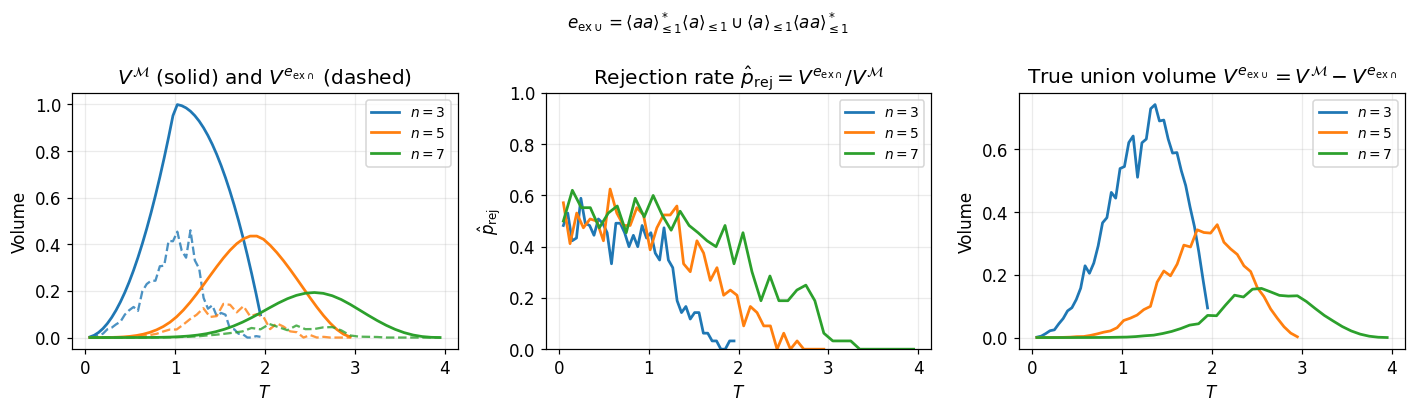

Saved 12_partB_volumes.pdf


In [12]:
colors_n = {3: "#1f77b4", 5: "#ff7f0e", 7: "#2ca02c"}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
for n, d in partB.items():
    c = colors_n[n]
    ax.plot(d["T"], d["v_M"],     color=c, lw=1.8, label=f"$n={n}$")
    ax.plot(d["T"], d["v_inter"], color=c, lw=1.5, linestyle="--", alpha=0.8)
ax.set_xlabel("$T$")
ax.set_ylabel("Volume")
ax.set_title(r"$V^{\mathcal{M}}$ (solid) and $V^{e_{\mathrm{ex}\cap}}$ (dashed)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

ax = axes[1]
for n, d in partB.items():
    v_M = np.array(d["v_M"]); v_i = np.array(d["v_inter"])
    safe = v_M > 1e-15
    ax.plot(np.array(d["T"])[safe], v_i[safe] / v_M[safe],
            color=colors_n[n], lw=1.8, label=f"$n={n}$")
ax.set_xlabel("$T$")
ax.set_ylabel(r"$\hat p_{\mathrm{rej}}$")
ax.set_title(r"Rejection rate $\hat p_{\mathrm{rej}} = V^{e_{\mathrm{ex}\cap}} / V^{\mathcal{M}}$")
ax.legend(fontsize=9); ax.set_ylim(0, 1); ax.grid(True, alpha=0.25)

ax = axes[2]
for n, d in partB.items():
    v_M = np.array(d["v_M"]); v_i = np.array(d["v_inter"])
    v_true = v_M - v_i
    ax.plot(d["T"], v_true, color=colors_n[n], lw=1.8, label=f"$n={n}$")
ax.set_xlabel("$T$")
ax.set_ylabel("Volume")
ax.set_title(r"True union volume $V^{e_{\mathrm{ex}\cup}} = V^{\mathcal{M}} - V^{e_{\mathrm{ex}\cap}}$")
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

fig.suptitle(
    r"$e_{\mathrm{ex}\cup}"
    r"= \langle aa\rangle^*_{\leq 1}\langle a\rangle_{\leq 1}"
    r"\cup \langle a\rangle_{\leq 1}\langle aa\rangle^*_{\leq 1}$",
    fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "12_partB_volumes.pdf"), bbox_inches="tight")
plt.show()
print("Saved 12_partB_volumes.pdf")


### Reading the plots

**Left panel — $V^{\mathcal{M}}$ and $V^{e_{\mathrm{ex}\cap}}$:**
- $V^{\mathcal{M}}$ (solid) is what `slice_volume` returns for `phi_union`.
  It equals $2\,V^{e_{\mathrm{left}}}$ and grows with $T$ (more time = more
  timed words), saturating once $T$ exceeds the tightest constraint.
- $V^{e_{\mathrm{ex}\cap}}$ (dashed, estimated) is the intersection volume —
  words matched by *both* branches.  It peaks around $T \approx 1$ where both
  constraints are roughly equally binding, then shrinks as $T \to 2$.
- Larger $n$ means higher-degree polynomials and smaller absolute volumes,
  but the same qualitative shape.

**Middle panel — rejection rate $\hat p_{\mathrm{rej}}$:**
- Near $T = 1$ roughly half of all draws are rejected, so sampling throughput
  is halved compared to an unambiguous expression.
- As $T \to 0$ or $T \to 2$ the intersection becomes small relative to
  $V^{\mathcal{M}}$, and the rejection rate drops.

**Right panel — true union volume:**
- $V^{e_{\mathrm{ex}\cup}} = V^{\mathcal{M}} - V^{e_{\mathrm{ex}\cap}}$
  is the actual set-theoretic volume of the union (paper eq 25).
- It is always $\leq V^{\mathcal{M}}$; the gap equals the intersection volume
  that was double-counted.

### Connection to Nicolas's rejection-rate experiment

Nicolas's request/grant expression for $k$ request types will also produce
**two distinct sources** of rejection:

| Source | Mechanism | Counter |
|---|---|---|
| Ambiguity | Multiple parse trees for the same word | `smart_rej` |
| Intersection (top-level `&`) | Match fails in second child | `intersect_rej` |

Part B isolates the first source.  For the full $e''_\mathcal{T}$ with $k \geq 2$,
both counters will be non-zero; measuring them separately (as the `Feedback` namedtuple
already supports) is the key step in Nicolas's bar-chart experiment.


---
## Summary

| Part | Expression | What we showed |
|---|---|---|
| **A** | $e''_\mathcal{T}$ (nested, optional requests) | Volume breakpoints at each $T_i$; sampling time polynomial in $k$ |
| **B** | $e_{\mathrm{ex}\cup}$ | $V^\mathcal{M} - V^{e_\cap}$ identity; rejection rate $\approx 30$–50% near $T=1$ |

**Nicolas's experiment**: measure `smart_rej` (ambiguity) and `intersect_rej`
(top-level `&`) separately for $e''_\mathcal{T}$ at $k = 5, 10, 15$;
compare VolTRE vs TA sampling times.
